In [32]:
from dotenv import load_dotenv
load_dotenv()

True

In [33]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from pydantic import BaseModel
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal

In [34]:
class EmailState(BaseModel):
    query: str = ""
    draft: str = ""
    human_feedback: str = ""
    final_response: str = ""

In [35]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [36]:
# defining the nodes

def draftEmail(state: EmailState) -> EmailState:
    # Implement the logic to draft an email based on the query
    draft = llm.invoke(f"""
    Draft email based on this user query: {state.query},
    Previous draft: \n{state.draft or "create a new draft"}\n
    Note: if you recive human feedback, incorporate it into the draft,
    human feedback: {state.human_feedback or "none"}
""").content
    
    # print(f"[draftEmail]: draft generated by AI based on \n Query: '{state.query}' \n Draft: \n{draft} \n\n")
    
    state.draft = draft
    return state 

In [37]:
def humanFeedback(state: EmailState) -> EmailState:
    # Implement the logic to get human feedback on the draft
    feedback = interrupt({
        "draft_email": state.draft,
        "question": "Do you approve this draft? or suggest changes."
    })
    feedback = (feedback or "").strip().lower()

    # If no feedback is provided, consider it as disapproval by default
    if feedback in ("approved", "yes", "okay"):
        state.human_feedback = ""
        print(f"[humanFeedback]: {state.human_feedback}")
    else:
        state.human_feedback = feedback
        print(f"[humanFeedback]: {state.human_feedback}")

    return state

In [38]:
def finalizedEmail(state: EmailState) -> EmailState:
    if state.human_feedback:
        state.final_response = state.human_feedback
        print(f"[finalizedEmail]: Mail not finalized due to disapproval.")
    else:
        state.final_response = "Email sent successfully ..."
        print(f"[finalizedEmail]: Mail finalized. Email sent successfully ...")

    return state

In [39]:
# either return to draftEmail if disapproved, or proceed to finalizedEmail if approved
def conditional_routing(state: EmailState) -> Literal["draftEmail", "finalizedEmail"]:
    if state.human_feedback:
        return "draftEmail"
    return "finalizedEmail"

In [40]:
# building graph
graph = StateGraph(EmailState)

# nodes 
graph.add_node("draftEmail", draftEmail)
graph.add_node("humanFeedback", humanFeedback)
graph.add_node("finalizedEmail", finalizedEmail)

# edges
graph.add_edge(START, "draftEmail")
graph.add_edge("draftEmail", "humanFeedback")
graph.add_conditional_edges("humanFeedback", conditional_routing)
graph.add_edge("finalizedEmail", END)

graph = graph.compile(checkpointer=InMemorySaver())

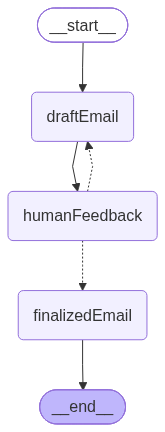

In [41]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [42]:
config = {"configurable": {"thread_id":"my_random_thread_id_R435y6tg5y6te34rgtevgsdfhrgherht"}}

In [43]:
res = graph.invoke({"query":"I want to send email for medical leave request "
"from date 11 oct to 13 oct 2026. create simple email."},config=config)
print("Assistant: \n", res['draft'], "\n")

Assistant: 
 **Subject:** Medical Leave Request (Oct 11‑13, 2026)

Dear [Manager’s Name],

I hope you are doing well. I am writing to request medical leave from **Monday, 11 October 2026 to Wednesday, 13 October 2026**. I will ensure all my current tasks are covered and will be reachable for any urgent matters.

Thank you for your understanding.

Best regards,

[Your Name]  
[Your Position]  
[Contact Information] 



In [44]:
res

{'query': 'I want to send email for medical leave request from date 11 oct to 13 oct 2026. create simple email.',
 'draft': '**Subject:** Medical Leave Request (Oct\u202f11‑13,\u202f2026)\n\nDear [Manager’s Name],\n\nI hope you are doing well. I am writing to request medical leave from **Monday, 11\u202fOctober\u202f2026 to Wednesday, 13\u202fOctober\u202f2026**. I will ensure all my current tasks are covered and will be reachable for any urgent matters.\n\nThank you for your understanding.\n\nBest regards,\n\n[Your Name]  \n[Your Position]  \n[Contact Information]',
 'human_feedback': '',
 'final_response': '',
 '__interrupt__': [Interrupt(value={'draft_email': '**Subject:** Medical Leave Request (Oct\u202f11‑13,\u202f2026)\n\nDear [Manager’s Name],\n\nI hope you are doing well. I am writing to request medical leave from **Monday, 11\u202fOctober\u202f2026 to Wednesday, 13\u202fOctober\u202f2026**. I will ensure all my current tasks are covered and will be reachable for any urgent mat

In [45]:
# now your loop gets interrupted by human feedback
# if you print res object, you'll see something like this:'__interrupt__': [Interrupt(value={'draft_email': '**Subject:** ...
# if you interrupt the loop and then resume with "yes", the process will continue from where it left off.
# if you interrupt the loop and then resume with "no", the process will not continue. And res will go back to draftEmail node.

res = graph.invoke(Command(resume="I want to change dates make it 14-16, in the end just mention only my name"),config=config)
print("Assistant: \n", res['draft'], "\n")


[humanFeedback]: i want to change dates make it 14-16, in the end just mention only my name
Assistant: 
 **Subject:** Medical Leave Request (Oct 14‑16, 2026)

Dear [Manager’s Name],

I hope you are doing well. I am writing to request medical leave from **Monday, 14 October 2026 to Wednesday, 16 October 2026**. I will ensure all my current tasks are covered and will be reachable for any urgent matters.

Thank you for your understanding.

Best regards,

[Your Name] 



In [46]:
# until last human feedback is approved, email drafting will continue
res = graph.invoke(Command(resume="yes"),config=config)
print("Assistant: final draft\n", res['draft'], "\n")


[humanFeedback]: 
[finalizedEmail]: Mail finalized. Email sent successfully ...
Assistant: final draft
 **Subject:** Medical Leave Request (Oct 14‑16, 2026)

Dear [Manager’s Name],

I hope you are doing well. I am writing to request medical leave from **Monday, 14 October 2026 to Wednesday, 16 October 2026**. I will ensure all my current tasks are covered and will be reachable for any urgent matters.

Thank you for your understanding.

Best regards,

[Your Name] 



In [47]:
# you can create a loop that interacts with the human in the email drafting process

# query = input("user: ")
# res = graph.invoke({"query": query}, config=config) # Run once to start the graph
# print("Assistant: \n", res['draft'], "\n")

# while True:
#     feedback = input("user: ")

#     if feedback.lower() in ["yes", "approved", "okay"]:
#         res = graph.invoke(Command(resume="yes"),config=config)
#         print("Assistant: final draft\n", res['draft'], "\n")

#         break
#     else:
#         res = graph.invoke(Command(resume=feedback),config=config)

#     print("Assistant: new draft\n", res['draft'], "\n")